# Phenotype Validation — `HGMD_TTN_processed.xlsx`

驗證模型輸出（8 個 mention/no_mention tissue counts）對應 ground truth `phenotype` 的正確性。

**對照表（model tissue bucket → ground truth phenotype）**

| Model bucket | GT phenotype |
|---|---|
| `Cardiac` | `cardiac` |
| `Skeletal` | `skeletal` |
| `Both` | `both` |
| `Not_Specified` | `unsure` |

**Notebook 結構**

- Layer 1：四種 decision rule（A / C / D / F）與比較
- Layer 2：confusion matrix、per-class P/R/F1、coverage、selective accuracy
- Layer 3：分層分析（PHEN / SVTYPE / RANKSCORE / mention–no_mention 衝突）
- Layer 4：bootstrap 95% CI

In [8]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)
sns.set_theme(style="white", context="talk")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 140

XLSX = Path("/home/ryan910702/ttn-agent/HGMD_TTN_processed (1).xlsx")
LABELS = ["cardiac", "skeletal", "both", "unsure"]
TISSUES = ["Cardiac", "Skeletal", "Both", "Not_Specified"]
TISSUE2LABEL = {"Cardiac": "cardiac", "Skeletal": "skeletal", "Both": "both", "Not_Specified": "unsure"}

MENTION_COLS = [f"mention_{t}" for t in TISSUES]
NOMENT_COLS = [f"no_mention_{t}" for t in TISSUES]
ALL_COUNT_COLS = MENTION_COLS + NOMENT_COLS

df = pd.read_excel(XLSX)
df[ALL_COUNT_COLS] = df[ALL_COUNT_COLS].fillna(0).astype(int)
# print("Shape:", df.shape)
# df.head(3)

## 0. 資料概覽

- 4 類 phenotype 的數量分佈
- 8 個 count 欄位的分佈（log scale）
- 「8 欄全 0」（模型啞口）的比例

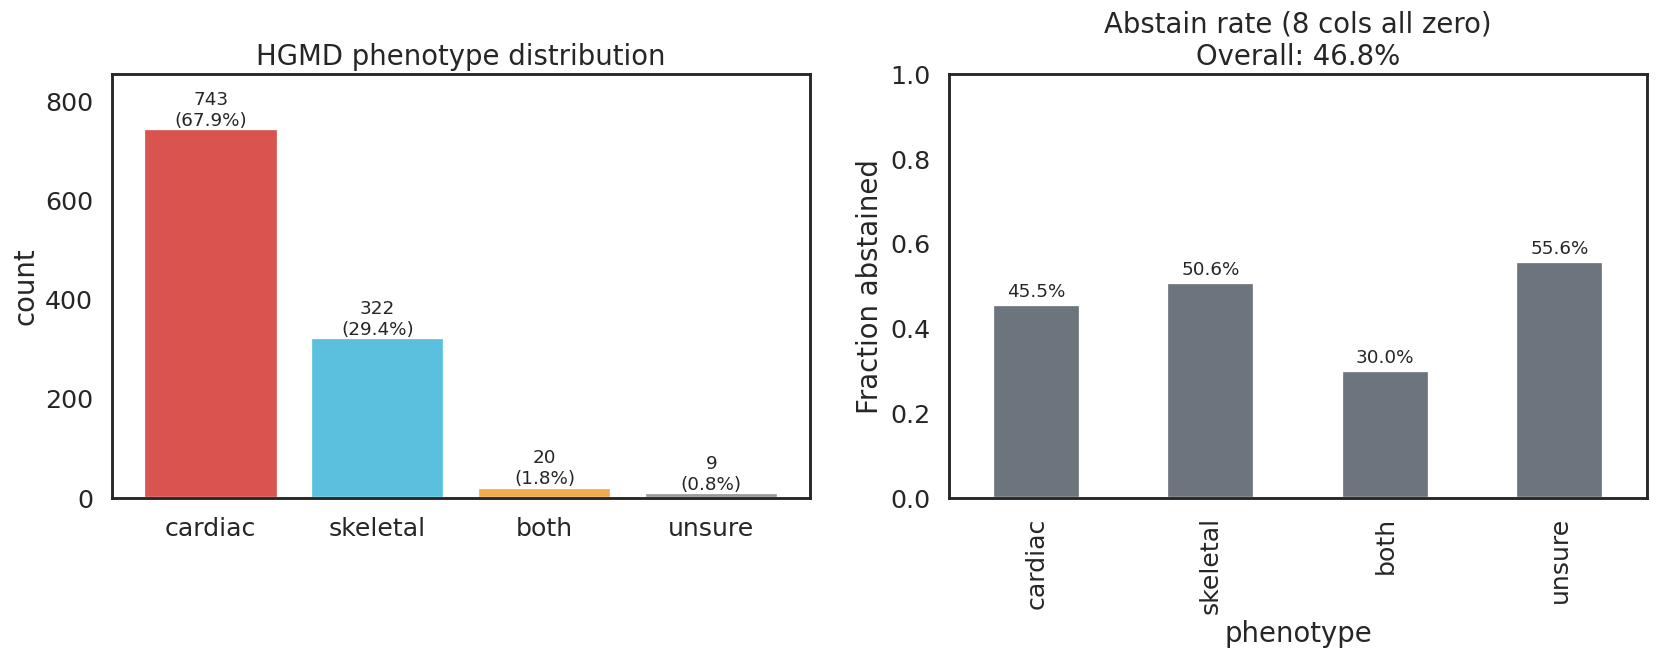

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

vc = df["phenotype"].value_counts().reindex(LABELS).fillna(0).astype(int)
axes[0].bar(vc.index, vc.values, color=["#d9534f", "#5bc0de", "#f0ad4e", "#999999"])
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 8, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=12)
axes[0].set_title("HGMD phenotype distribution")
axes[0].set_ylabel("count")
axes[0].set_ylim(0, vc.max() * 1.15)

zero_mask = (df[ALL_COUNT_COLS].sum(axis=1) == 0)
abstain_by_label = df.groupby("phenotype")[ALL_COUNT_COLS].apply(lambda g: (g.sum(axis=1) == 0).mean()).reindex(LABELS)
abstain_by_label.plot(kind="bar", ax=axes[1], color="#6c757d")
axes[1].set_title(f"Abstain rate (8 cols all zero)\nOverall: {zero_mask.mean()*100:.1f}%")
axes[1].set_ylabel("Fraction abstained")
axes[1].set_ylim(0, 1)
for i, v in enumerate(abstain_by_label.values):
    axes[1].text(i, v + 0.02, f"{v*100:.1f}%", ha="center", fontsize=12)

# plt.tight_layout()
plt.show()

# print(f"\nAbstain (all-zero) rows: {zero_mask.sum()}/{len(df)} = {zero_mask.mean()*100:.1f}%")

## Layer 1 — Decision rules

> **過濾**：先把 8 個 count 全為 0 的列（模型完全沒抓到文獻證據）剔除，只在「模型有訊號」的子集上做驗證。

把 8 個 counts 映射到 4 類 phenotype 的兩種規則：

- **Rule C — mention-first fallback**：`mention_*` 有訊號就用它取 argmax；否則 fallback 用 `no_mention_*` 取 argmax。
- **Rule D — ignore Not_Specified**：四桶中拿掉 `Not_Specified`，只比 Cardiac / Skeletal / Both（用 `mention + no_mention` 加總）。

In [10]:
n_before = len(df)
df = df[df[ALL_COUNT_COLS].sum(axis=1) > 0].reset_index(drop=True).copy()
ABSTAIN = "abstain"

def _argmax_tissue(row, cols):
    vals = np.array([row[c] for c in cols], dtype=float)
    if vals.sum() == 0:
        return ABSTAIN
    idx = int(np.argmax(vals))
    return TISSUE2LABEL[TISSUES[idx]]

def rule_C_mention_first(row):
    p = _argmax_tissue(row, MENTION_COLS)
    if p != ABSTAIN:
        return p
    return _argmax_tissue(row, NOMENT_COLS)

def rule_D_no_notspec(row):
    cols3 = ["Cardiac", "Skeletal", "Both"]
    vals = np.array([row[f"mention_{t}"] + row[f"no_mention_{t}"] for t in cols3], dtype=float)
    if vals.sum() == 0:
        return ABSTAIN
    return TISSUE2LABEL[cols3[int(np.argmax(vals))]]

pred = pd.DataFrame(index=df.index)
pred["C_fallback"] = df.apply(rule_C_mention_first, axis=1)
pred["D_no_notspec"] = df.apply(rule_D_no_notspec, axis=1)
pred["truth"] = df["phenotype"].values
# pred.head()

In [11]:
def _mask_abstain(y_true, y_pred):
    """回傳 (y_true, y_pred) 兩個 numpy array，已移除 y_pred == ABSTAIN 的列。"""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_pred != ABSTAIN
    return y_true[mask], y_pred[mask]


def acc(y_true, y_pred):
    """Accuracy，自動忽略 abstain 預測的列。"""
    yt, yp = _mask_abstain(y_true, y_pred)
    return (yt == yp).mean() if len(yt) else np.nan


def evaluate(y_true, y_pred):
    """abstain 直接忽略；accuracy 只在「模型有給預測」的列上計算。"""
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)
    mask = y_pred_arr != ABSTAIN
    return {
        "accuracy": (y_true_arr[mask] == y_pred_arr[mask]).mean() if mask.any() else np.nan,
        "n_evaluated": int(mask.sum()),
        "n_abstain": int((~mask).sum()),
    }


rules = ["C_fallback", "D_no_notspec"]
summary = pd.DataFrame({r: evaluate(pred["truth"], pred[r]) for r in rules}).T
summary = summary.round(4)
summary

,accuracy,n_evaluated,n_abstain
C_fallback,0.7079,582.0,0.0
D_no_notspec,0.7599,554.0,28.0


## Layer 2 — 細部 metrics

對四種 rule 各畫一張 confusion matrix（row-normalized），再用 macro-F1 最高者畫 per-class P/R/F1。

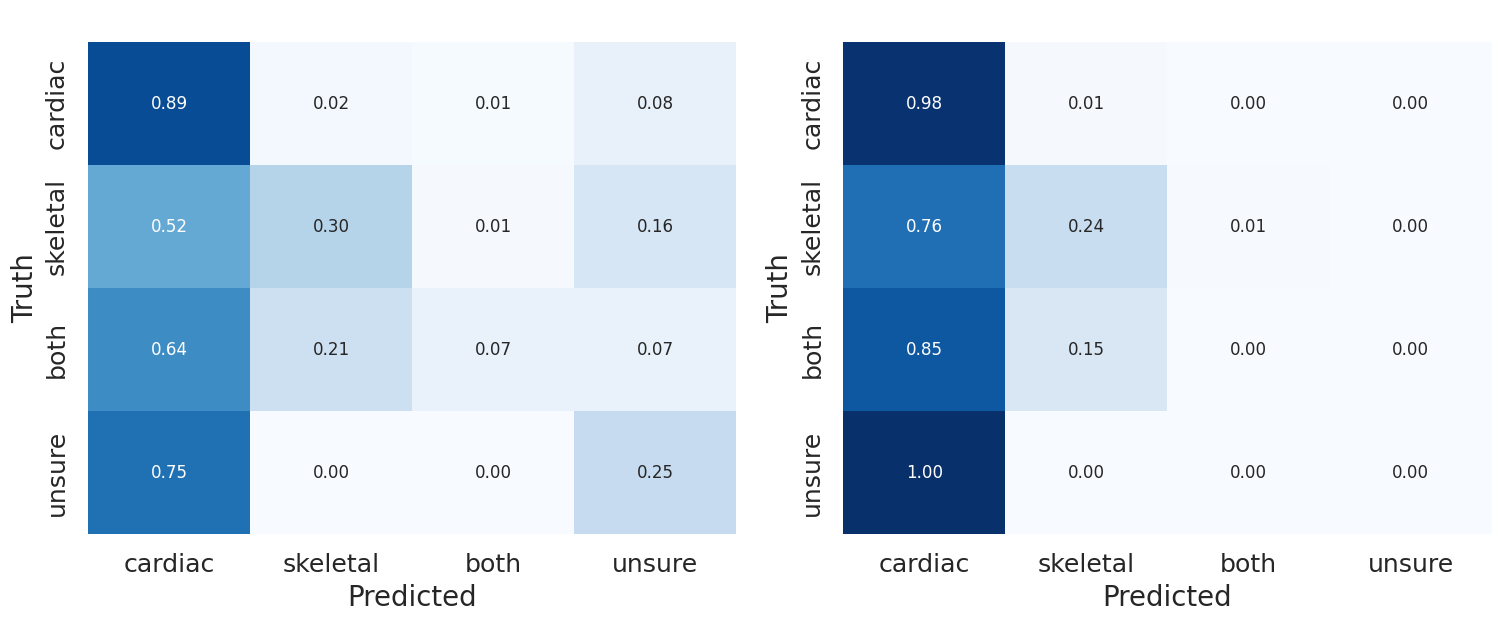

In [12]:
fig, axes = plt.subplots(1, len(rules), figsize=(7 * len(rules), 6))
if len(rules) == 1:
    axes = np.array([axes])
for ax, rule in zip(axes.flat, rules):
    yt, yp = _mask_abstain(pred["truth"], pred[rule])
    cm = confusion_matrix(yt, yp, labels=LABELS)
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_norm, annot=cm_norm, fmt=".2f", cmap="Blues", cbar=False,
                xticklabels=LABELS, yticklabels=LABELS, ax=ax,
                vmin=0, vmax=1, annot_kws={"size": 11})
    n_abs = int((pred[rule] == ABSTAIN).sum())
    ax.set_title(f" ")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Truth")
plt.tight_layout()
plt.show()

In [13]:
def per_class_metrics(rule):
    yt, yp = _mask_abstain(pred["truth"], pred[rule])
    prec, rec, f1, support = precision_recall_fscore_support(
        yt, yp, labels=LABELS, zero_division=0
    )
    m_prec, m_rec, m_f1, _ = precision_recall_fscore_support(
        yt, yp, labels=LABELS, average="macro", zero_division=0
    )
    w_prec, w_rec, w_f1, _ = precision_recall_fscore_support(
        yt, yp, labels=LABELS, average="weighted", zero_division=0
    )
    out = pd.DataFrame({"precision": prec, "recall": rec, "f1": f1, "support": support},
                       index=LABELS)
    out.loc["macro avg"] = [m_prec, m_rec, m_f1, int(support.sum())]
    out.loc["weighted avg"] = [w_prec, w_rec, w_f1, int(support.sum())]
    return out.round(3)


for rule in rules:
    print(f"=== {rule} ===")
    print(per_class_metrics(rule))
    print()

=== C_fallback ===
              precision  recall     f1  support
cardiac           0.792   0.894  0.840    405.0
skeletal          0.814   0.302  0.440    159.0
both              0.143   0.071  0.095     14.0
unsure            0.017   0.250  0.032      4.0
macro avg         0.441   0.379  0.352    582.0
weighted avg      0.777   0.708  0.707    582.0

=== D_no_notspec ===
              precision  recall     f1  support
cardiac           0.757   0.985  0.856    393.0
skeletal          0.829   0.236  0.368    144.0
both              0.000   0.000  0.000     13.0
unsure            0.000   0.000  0.000      4.0
macro avg         0.397   0.305  0.306    554.0
weighted avg      0.753   0.760  0.703    554.0



## Layer 3 — 分層分析

- 各 PHEN（前 15 大）下，每個 rule 的 accuracy
- SVTYPE × accuracy
- RANKSCORE 分箱 × accuracy
- mention 與 no_mention 衝突案例的正確率

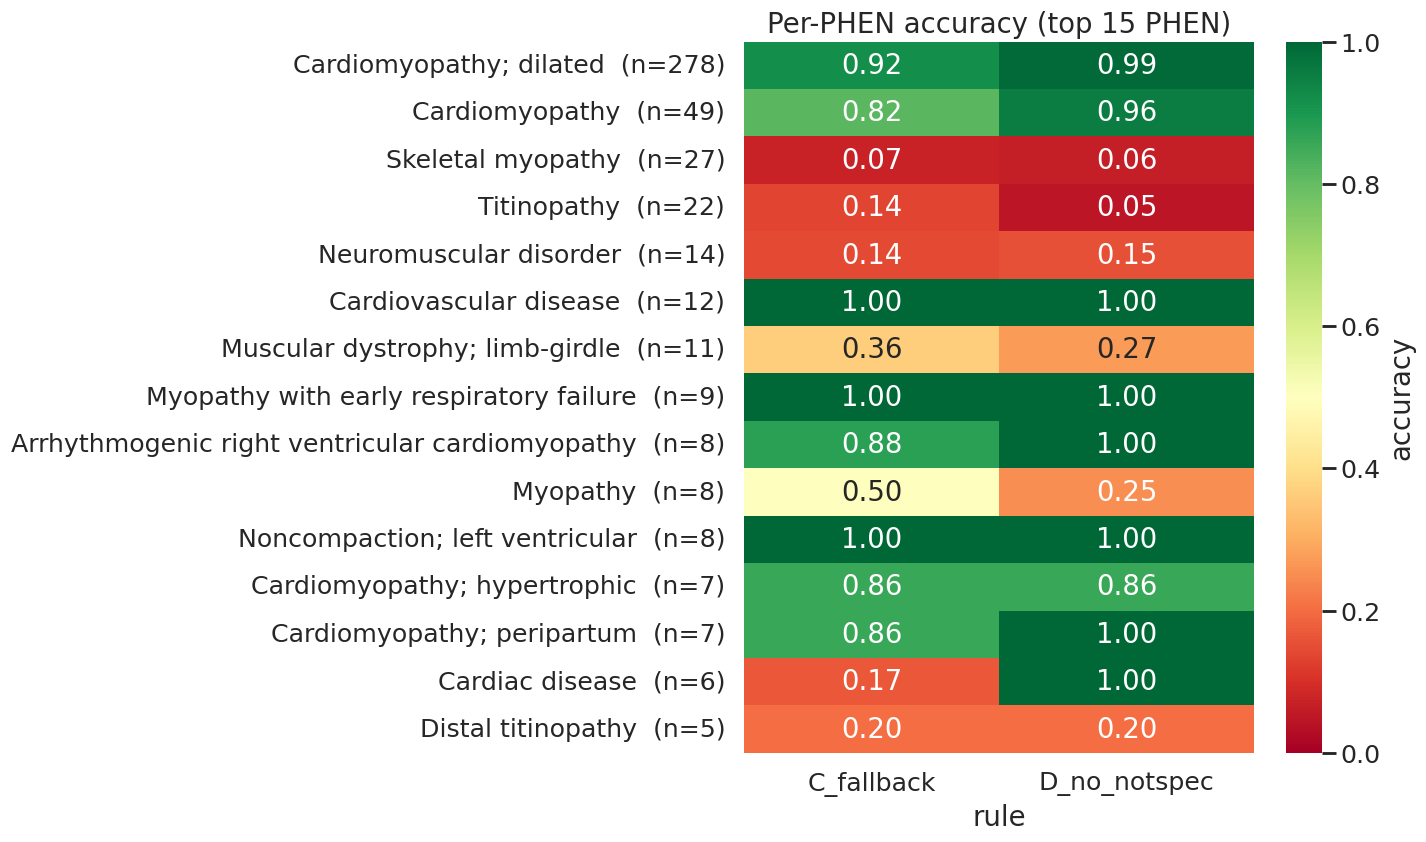

In [14]:
top_phen = df["PHEN"].value_counts().head(15).index.tolist()

acc_by_phen = {}
for phen in top_phen:
    mask = (df["PHEN"] == phen).values
    accs = {r: acc(pred.loc[mask, "truth"].values, pred.loc[mask, r].values)
            for r in rules}
    accs["n"] = int(mask.sum())
    acc_by_phen[phen] = accs

acc_phen_df = pd.DataFrame(acc_by_phen).T
acc_phen_df = acc_phen_df.sort_values("n", ascending=False)

fig, ax = plt.subplots(figsize=(13, 8))
heat = acc_phen_df[rules].astype(float)
sns.heatmap(heat, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
            cbar_kws={"label": "accuracy"}, ax=ax,
            yticklabels=[f"{p}  (n={int(acc_phen_df.loc[p,'n'])})" for p in acc_phen_df.index])
ax.set_title("Per-PHEN accuracy (top 15 PHEN)")
ax.set_xlabel("rule")
plt.tight_layout()
plt.show()